# Place cells data priming

In [1]:
import os
import pandas as pd
import csv
import re
from pathlib import Path
import numpy as np
import scipy.ndimage as ndi
import logging
import pynapple as nap
import seaborn as sns
from scipy.ndimage import label, find_objects
from pynwb import NWBHDF5IO, NWBFile, TimeSeries
from pynwb.behavior import (
    BehavioralEpochs,
    BehavioralEvents,
    BehavioralTimeSeries,
    CompassDirection,
    EyeTracking,
    Position,
    PupilTracking,
    SpatialSeries,
)
from neuroconv.datainterfaces import Suite2pSegmentationInterface
from zoneinfo import ZoneInfo
import caiman 
import matplotlib.pyplot as plt
from uuid import uuid4
from datetime import datetime
from dateutil.tz import tzlocal
from pynwb.epoch import TimeIntervals
from pynwb.misc import IntervalSeries
import tifffile

source = Path(r"E:\Szbl\Datas\PlaceCell\H93\251104\PC08250504")

d:\BasicTools\anaconda\envs\PC\lib\site-packages\caiman\__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def extract_rep_number(filename):
    """从文件名中提取rep后的数字"""
    match = re.search(r'_rep(\d+)_', filename)
    return int(match.group(1)) if match else 0

def process_files(input_dir, output_csv):
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    
    # 获取并排序文件
    files = []
    for f in Path(input_dir).glob("*.txt"):
        try:
            rep_num = extract_rep_number(f.name)
            files.append((rep_num, f))
        except:
            print(f"跳过无法解析的文件: {f.name}")
            continue
    files.sort(key=lambda x: x[0])
    
    # 写入CSV
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        for rep_num, filepath in files:
            with open(filepath, 'r', encoding='utf-8') as txtfile:
              
                
                for line in txtfile:
                    # 清洗并分割数据
                    clean_line = line.strip().replace('\r', '').replace('\n', '')
                    if not clean_line:
                        continue
                    
                    # 按逗号分割为多列
                    row_data = clean_line.split(',')
               
                    writer.writerow(row_data)

def ConvertBehavior (source, output_dir):

    scale = 1.000

    df = pd.read_csv(source, header=None)
    # get data 
    first_column = df.iloc[:, 8]
    differences_from_first = (first_column - first_column.iloc[0])/1000
    print(differences_from_first)

    # Update time
    df['Time'] = differences_from_first 
    df.to_csv(source, index=False)

    nwbfile = NWBFile(
    session_description="G7_20250114",
    identifier=str(uuid4()),
    session_start_time=datetime.now(tzlocal()),
    experimenter=[
        "Ming",
    ],
    lab="Xian Jiang Laboratory",
    institution="Shenzhen Bay Laboratory",
    experiment_description="Virtual linear track",
    session_id="Day10",
    )

    temp = df.iloc[:, 4].values

    position_data = np.interp(temp,[-2,2],[0,400])
    print(temp.shape)
    timestamps = df.iloc[:, 9].values *scale

    position_spatial_series = SpatialSeries(
        name="SpatialSeries",
        description="Position in a virtual track.",
        data=position_data,
        timestamps=timestamps,
        reference_frame="Start point",
    )

    position = Position(spatial_series=position_spatial_series)

    behavior_module = nwbfile.create_processing_module(
    name="behavior", description="Processed behavioral data"
    )

    behavior_module.add(position)

    # 读取 CSV 文件，只读取 position 和 time 对应的列
    data = pd.read_csv(source, usecols=[4, 9])

    # 找到第一列值为 0.96 的所有行的索引
    current_indices = data.index[data.iloc[:, 0] == 2].tolist()

    # 初始化 stop_time 和 start_time 列表
    stop_times = []
    start_times = []

    print(data)
    


    # 遍历每个当前索引，获取当前行和下一行的值
    for index in current_indices:
        if index + 1 < len(data):  # 确保下一个索引存在
            stop_times.append(data.iloc[index, 1]*scale)  # 当前行的第三列值作为 stop_time
            start_times.append(data.iloc[index + 1, 1]*scale)  # 下一行的第三列值作为 start_time
        else:
            stop_times.append(data.iloc[index, 1]*scale)  # 最后一行时，没有下一行，只添加 stop_time
            # start_times.append(None)  # 对应的 start_time 为 None

    start_times.insert(0,0)
    laps = list(range(1, len(start_times)+1))
    print("Stop Times:", len(stop_times),stop_times,)
    print("Start Times:", len(start_times),start_times)

    if not (len(start_times) == len(stop_times) == len(laps)):
        print("Warning: Lists are of unequal length.")

    Running_laps = TimeIntervals(
    name="Running_laps",
    description="Running laps.",
    )

    Running_laps.add_column(name="lap", description="The lap of running.")

    for start_time, stop_time, lap in zip(start_times, stop_times, laps):
        Running_laps.add_row(start_time=start_time, stop_time=stop_time, lap=lap)

    nwbfile.add_time_intervals(Running_laps)

    temp = df.iloc[:, 7].values

    series = pd.Series(temp)

    # 使用shift()和比较操作找出不同的元素
    changes = series != series.shift(1)

    # 获取改变点的索引
    indices_of_changes = changes[changes].index.tolist()

    selected_rows = df.iloc[indices_of_changes, 9].values *scale  # 读取第二列中对应索引的值
    
    # 转换成数组或者Pandas Series，这里为了一致性，我们继续使用Pandas Series
    new_series = pd.Series(selected_rows)

    # print("新的数组包含以下值:")
    lick_time = np.array(new_series)

    reward_amount = np.ones(lick_time.shape)
    events_timestamps = lick_time

    time_series = TimeSeries(
        name="licking",
        data=reward_amount,
        timestamps=events_timestamps,
        description="The lick number the subject received as a reward.",
        unit="ul",
    )

    behavioral_events = BehavioralEvents(time_series=time_series, name="BehavioralEvents")

    behavior_module.add(behavioral_events)

    save_path = output_dir / "behavior.nwb"

    with NWBHDF5IO(save_path, "w") as io:
        io.write(nwbfile)

def ExtractDFF():
    return
    

def Calcium():
    interface = Suite2pSegmentationInterface(folder_path=calcium_path, verbose=False)
    metadata = interface.get_metadata()
    session_start_time = datetime(2020, 1, 1, 12, 30, 0, tzinfo=ZoneInfo("US/Pacific"))
    metadata["NWBFile"].update(session_start_time=session_start_time)
    
    nwbfile_path = calcium_path / "calcium.nwb"  
    interface.run_conversion(nwbfile_path=nwbfile_path, metadata=metadata)


def calculate_noise_levels(neurons_x_time, frame_rate):

    """"
    Computes the noise levels for each neuron of the input matrix 'dF_traces'.

    The noise level is computed as the median absolute dF/F difference
    between two subsequent time points. This is a outlier-robust measurement
    that converges to the simple standard deviation of the dF/F trace for
    uncorrelated and outlier-free dF/F traces.

    Afterwards, the value is divided by the square root of the frame rate
    in order to make it comparable across recordings with different frame rates.


    input: dF_traces (matrix with nb_neurons x time_points)
    output: vector of noise levels for all neurons

    """
    dF_traces = neurons_x_time
    noise_levels = np.nanmedian(np.abs(np.diff(dF_traces, axis=-1)), axis=-1) / np.sqrt(frame_rate)
    return noise_levels * 100     # scale noise levels to percent

def plot_noise_level_distribution(traces,frame_rate):

  """
  Plots a histogram of the noise levels across all neurons in the dataset

  """
  try:
    import seaborn as sns; sns.set()
    plt.style.use('seaborn-darkgrid')
  except:
    pass

  noise_levels = calculate_noise_levels(traces, frame_rate)
  
  percent999 = np.nanpercentile(noise_levels,99.9)

  plt.figure(1121); plt.hist(noise_levels,density=True, bins=100)
  plt.xlim([0, percent999])
  plt.xlabel('Noise level (% s^(1/2))')
  plt.title('Histogram of noise levels across neurons')

  return noise_levels

def check_time(output_csv):
    df = pd.read_csv(output_csv, header=None)
    # get data 


    rows = []
    timestemps = df.iloc[:, 6]
    print(len(timestemps))
    i = 0
    while i < len(timestemps):
        if timestemps[i] == 1:
            rows.append(i)
        i += 1

    delta_Ts = []
    times = df.iloc[:,9]
   
    
    j = 0
    while j < len(rows):
            if j == 0:
                
                delta_T = round(float(times[rows[j]]), 3)

            else: 
                 delta_T = round(float(times[rows[j]]) - float(times[rows[j-1]]), 3)
            j += 1

            delta_Ts.append(delta_T)

    print(f"time interval between timestamps is: \n{delta_Ts}")


In [3]:
behavior_dir = source / "behavior"
output_path = source / "outputs"
os.makedirs(output_path, exist_ok=True)

output_csv = output_path / "combined.csv"
print(output_csv)

session_description="PC08_20250503"
identifier=str(uuid4())
session_start_time=datetime.now(tzlocal())
experimenter=["Ming", "Qiyuan"]
lab="Xian Jiang Laboratory"
institution="Shenzhen Bay Laboratory"
experiment_description="Virtual linear track"

ops_path = source / "suite2p" / "plane0" / "ops.npy"
ops = np.load(ops_path, allow_pickle=True).item()
mean_img = ops['meanImg']
mean_img_norm = mean_img - mean_img.min()
mean_img_norm /= mean_img_norm.max()
mean_img_uint8 = (mean_img_norm * 255).astype(np.uint8)
# 保存为 .tif 文件
img_output_path = output_path / "mean_image.tif"
tifffile.imwrite(img_output_path, mean_img_uint8)

process_files(behavior_dir, output_csv)

ConvertBehavior(output_csv, output_path)
check_time(output_csv=output_csv)

E:\Szbl\Datas\PlaceCell\H93\251104\PC08250504\outputs\combined.csv
0           0.000
1           0.015
2           0.061
3           0.079
4           0.108
           ...   
33442    1226.318
33443    1226.338
33444    1226.390
33445    1226.410
33446    1226.461
Name: 8, Length: 33447, dtype: float64
(33447,)
             4      Time
0     -2.00000     0.000
1     -2.00000     0.015
2     -2.00000     0.061
3     -2.00000     0.079
4     -2.00000     0.108
...        ...       ...
33442  1.97710  1226.318
33443  1.98115  1226.338
33444  1.99195  1226.390
33445  1.99600  1226.410
33446  2.00000  1226.461

[33447 rows x 2 columns]
Stop Times: 39 [36.055, 55.728, 81.188, 107.673, 134.486, 165.195, 189.649, 219.88, 247.638, 274.814, 303.995, 336.305, 367.326, 392.893, 423.511, 459.319, 487.414, 521.332, 552.338, 585.423, 618.768, 658.48, 687.195, 722.49, 751.619, 788.132, 815.065, 848.01, 890.049, 924.555, 952.786, 1001.678, 1032.061, 1066.832, 1094.382, 1127.944, 1159.617, 1189.349, 122

d:\BasicTools\anaconda\envs\PC\lib\site-packages\hdmf\build\objectmapper.py:267: DtypeConversionWarning: Spec 'TimeIntervals/start_time': Value with data type int32 is being converted to data type float32 as specified.
  warnings.warn(full_warning_msg, DtypeConversionWarning)


time interval between timestamps is: 
[119.38, 0.017, 120.116, 120.088, 120.114, 120.11, 120.083, 0.021, 120.075, 0.019, 120.092, 120.107, 0.019]


In [4]:
behavior_path = output_path / "behavior.nwb"
behavior_data = nap.load_file(behavior_path)
print(behavior_data)
position = behavior_data['SpatialSeries']
epochs = behavior_data['Running_laps']
lick = behavior_data['licking']
print(lick)


behavior
┍━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys          │ Type        │
┝━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ Running_laps  │ IntervalSet │
│ SpatialSeries │ Tsd         │
│ licking       │ Tsd         │
┕━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙
Time (s)
----------  --
0.0          1
30.23        1
31.113       1
31.392       1
31.545       1
31.807       1
31.947       1
...
1212.62      1
1212.779     1
1212.922     1
1213.1       1
1213.317     1
1213.456     1
1213.647     1
dtype: float64, shape: (1074,)


In [5]:
neucoeff = 0.7 # neuropil coefficient
F_path = source / "suite2p" / "plane0" / "F.npy"
Fneu_path = source / "suite2p" / "plane0" / "Fneu.npy"
spks_path = source / "suite2p" / "plane0" / "spks.npy"
iscell_path = source / "suite2p" / "plane0" / "iscell.npy"
stat_path = source / "suite2p" / "plane0" / "stat.npy"

backup_path = source / "backup"
os.makedirs(backup_path, exist_ok=True)



F = np.load(F_path)
Fneu = np.load(Fneu_path)
spks = np.load(spks_path)
iscell = np.load(iscell_path)
stat = np.load(stat_path, allow_pickle=True)


np.save(backup_path/"F.npy", F)
np.save(backup_path/"Fneu.npy", Fneu)
np.save(backup_path/"spks.npy", spks)
np.save(backup_path/"iscell.npy", iscell)
np.save(backup_path/"stat.npy", stat)
np.save(output_path/"stat.npy", stat)

Fc = F - neucoeff * Fneu
Fc.shape

(3221, 36000)

In [6]:
def compute_dff(C, quantileMin=8, frames_window=500, flag_auto=True, use_fast=False, detrend_only=False):
    """ Compute DF/F signal from the temporal components (C).
        DF = (F -F0) / F0
    Args:
        C: ndarray
            Temporal components (from cnmf cnm.C)
        
        quantileMin: float
            Quantile used to estimate the baseline (values in [0,100])
        
        frames_window: int
            Number of frames for computing running quantile
        
        flag_auto: bool
            Flag for determining quantile automatically
        
        use_fast: bool
            Flag for using approximate fast percentile filtering
        
        detrend_only: bool (False)
            Flag for only subtracting baseline and not normalizing by it.
    
    Returns:
        F_df: ndarray
            The computed DF/F signal
    """
    
    if C is None:
        logging.warning("There are no temporal components for DF/F extraction!")
        return None
    
    # Number of frames
    T = C.shape[-1]

    if flag_auto:
        # Calculate baseline using the first part of C if windowing
        data_prct, val = caiman.utils.stats.df_percentile(C[:, :frames_window], axis=1)
        if frames_window is None or frames_window > T:
            Fd = np.stack([np.percentile(f, quantileMin) for f in C])
            if not detrend_only:
                F_df = (C - Fd[:, None]) / (Fd[:, None] + Fd[:, None])
            else:
                F_df = C - Fd[:, None]
        else:
            if use_fast:
                # Use fast filtering
                Fd = np.stack([fast_prct_filt(f, level=quantileMin, frames_window=frames_window) for f in C])
            else:
                # Use percentile filter
                Fd = np.stack([ndi.percentile_filter(f, quantileMin, (frames_window)) for f in C])
            if not detrend_only:
                # F_df = (C - Fd) / (Fd + Fd)
                F_df = (C - Fd) / Fd 
            else:
                F_df = C - Fd
    else:
        # Use manual quantile calculation
        Fd = np.percentile(C, quantileMin, axis=1)
        if not detrend_only:
            F_df = (C - Fd[:, None]) / (Fd[:, None] + Fd[:, None])
        else:
            F_df = C - Fd[:, None]

    return F_df

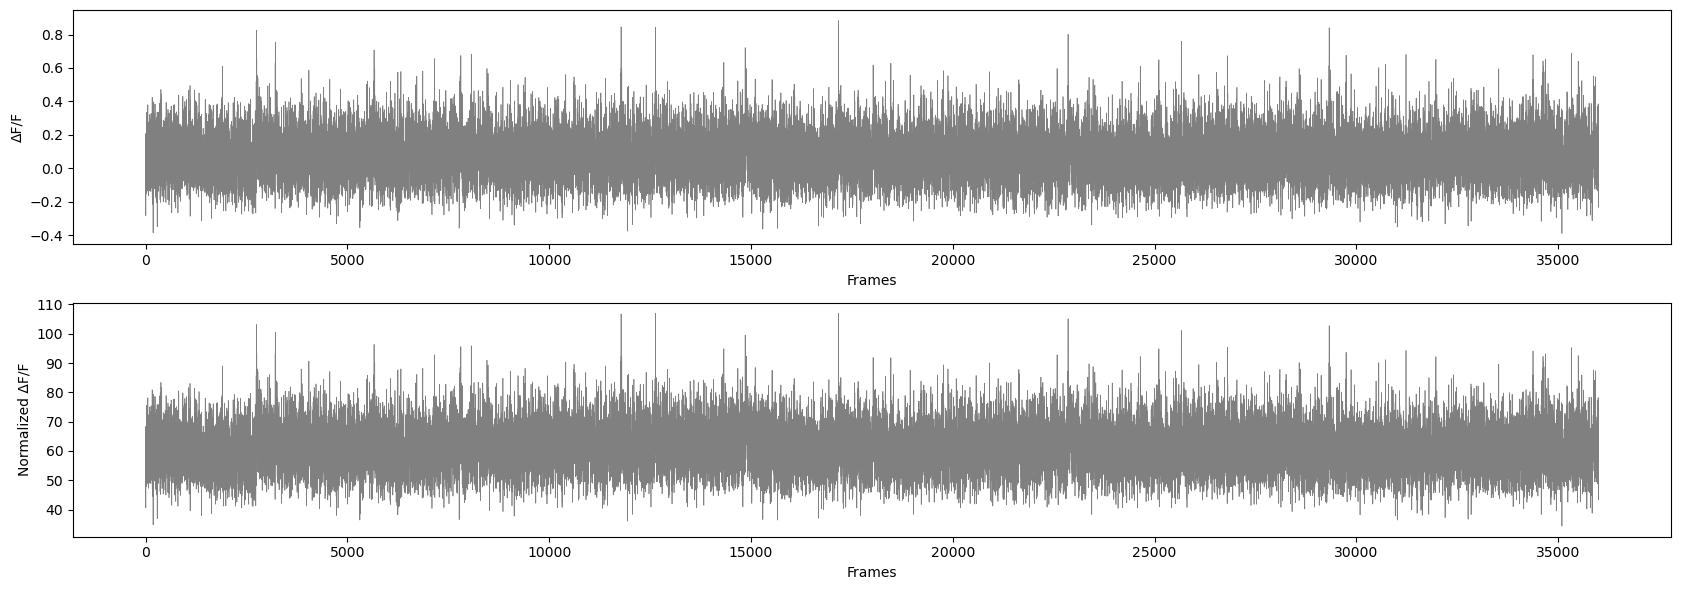

In [7]:
F_df = compute_dff(Fc, quantileMin=30, frames_window=1800, flag_auto=True, use_fast=False, detrend_only=False)
F_df_normalized = (F_df - np.mean(F_df, axis=1, keepdims=True)) / np.std(F_df, axis=1, keepdims=True)

neuro_idx = 50
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)  
plt.plot(F_df[neuro_idx , :], color = 'gray',linewidth=0.5)
plt.xlabel("Frames")
plt.ylabel("ΔF/F")

plt.subplot(2, 1, 2)  
plt.plot(F[neuro_idx , :], color = 'gray',linewidth=0.5)
plt.xlabel("Frames")
plt.ylabel("Normalized ΔF/F")

plt.tight_layout()  
plt.show()

1.7865036


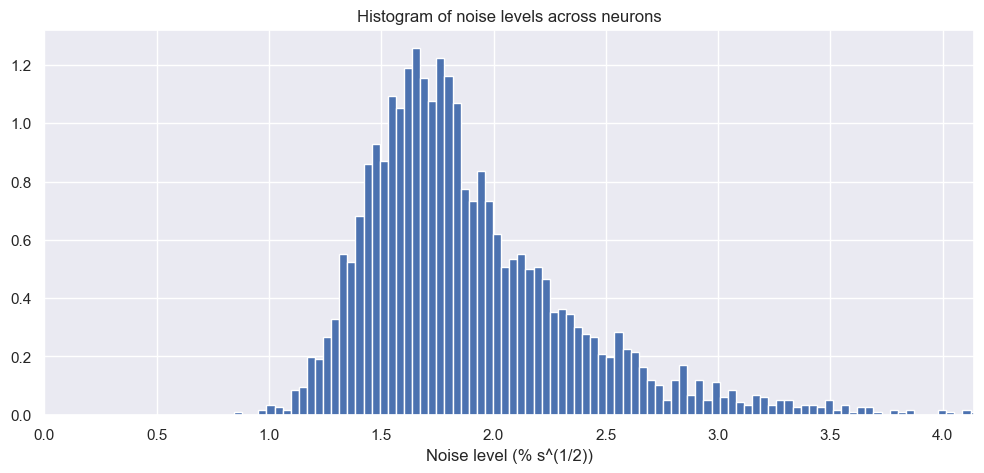

In [8]:
frame_rate = 30

plt.rcParams['figure.figsize'] = [12,5]

noise_level = plot_noise_level_distribution(F_df, frame_rate)

meadian_noise_level = np.median(noise_level)
print(meadian_noise_level)

Detection finished


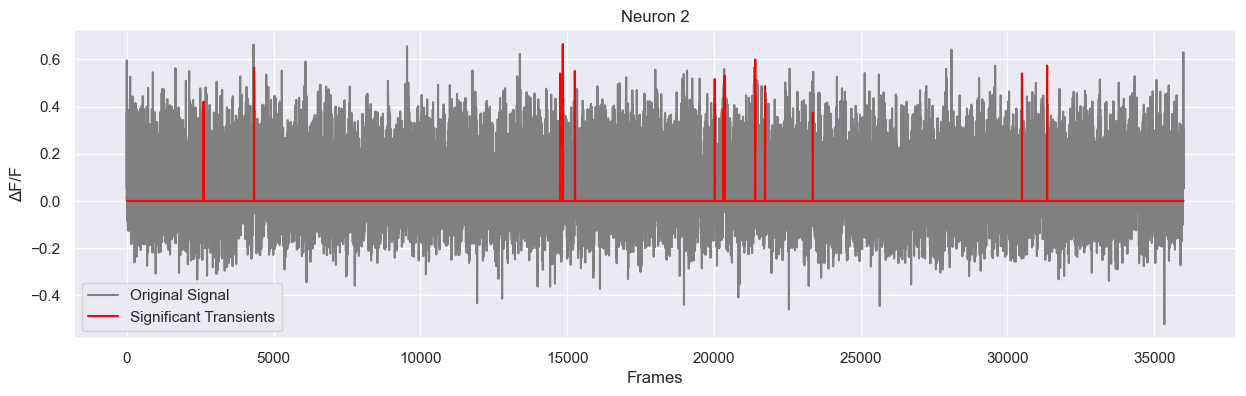

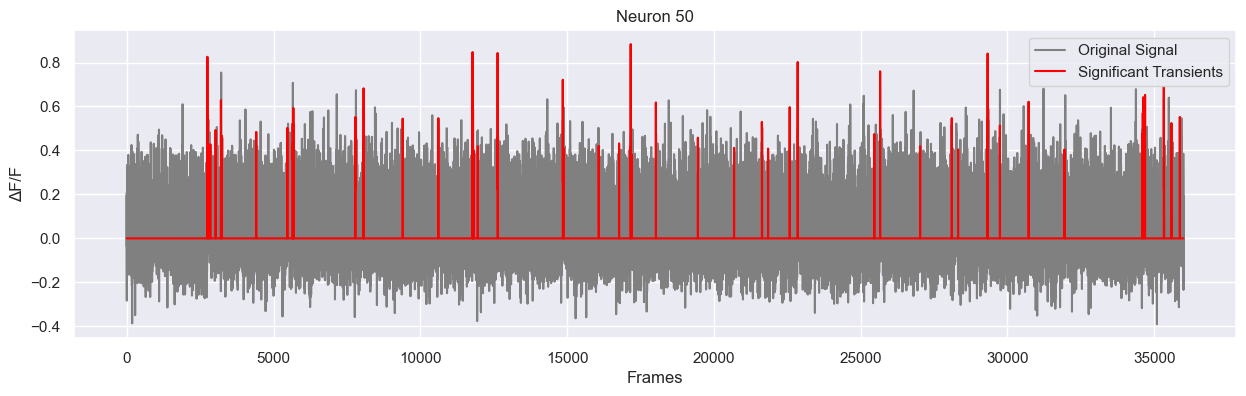

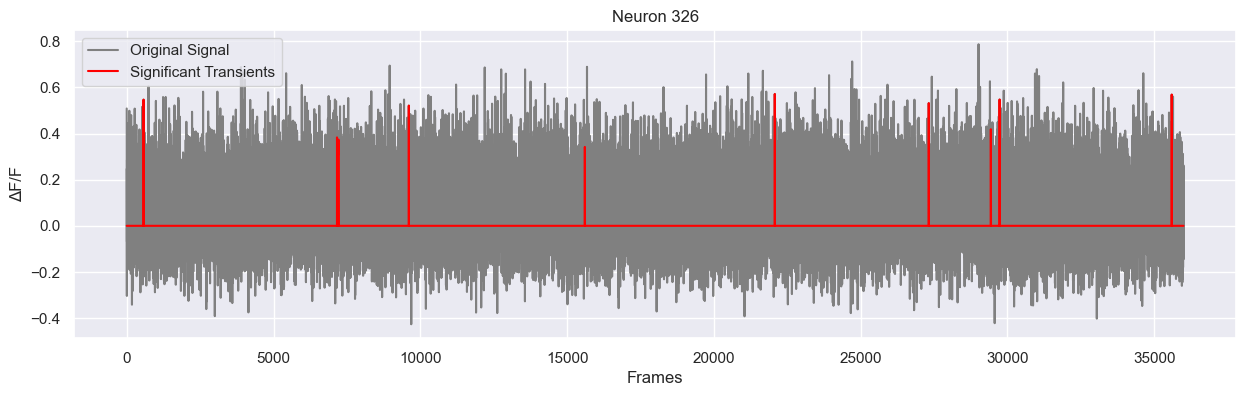

In [9]:
final_signals = np.zeros_like(F_df_normalized)

thresholds = np.arange(1, 4.2, 0.2)  # set threshold

num_neurons, num_frames = F_df_normalized.shape

# Assume F_df_normalized and F_df are NumPy arrays with shape (473, 18000)
# Initialize a matrix to store the final significant transient signals for all neurons (based on F_df)
final_signals = np.zeros_like(F_df)  # Note that this uses the shape of F_df

# Set threshold range
thresholds = np.arange(1, 4.2, 0.2)  # Thresholds range from 1 to 4 with a step of 0.2

num_neurons, num_frames = F_df_normalized.shape

for neuro_index in range(num_neurons):
    # Use the normalized signal for detection
    signal_normalized = F_df_normalized[neuro_index, :]
    significant_frames = np.zeros_like(signal_normalized, dtype=bool)
    
    for t in thresholds:
        # Identify positive transients above the threshold
        above_thresh = signal_normalized > t
        # Find consecutive segments of positive transients
        positive_transients = []
        idx = np.where(above_thresh)[0]
        if idx.size > 0:
            starts = [idx[0]]
            ends = []
            for i in range(1, len(idx)):
                if idx[i] != idx[i-1] + 1:
                    ends.append(idx[i-1])
                    starts.append(idx[i])
            ends.append(idx[-1])
            # Record the start and end positions of the positive transients
            positive_transients = list(zip(starts, ends))
        
        # Similarly handle negative transients below the threshold
        below_thresh = signal_normalized < -t
        negative_transients = []
        idx_neg = np.where(below_thresh)[0]
        if idx_neg.size > 0:
            starts = [idx_neg[0]]
            ends = []
            for i in range(1, len(idx_neg)):
                if idx_neg[i] != idx_neg[i-1] + 1:
                    ends.append(idx_neg[i-1])
                    starts.append(idx_neg[i])
            ends.append(idx_neg[-1])
            # Record the start and end positions of the negative transients
            negative_transients = list(zip(starts, ends))
        
        # Classify transients by their length n
        positive_lengths = [end - start + 1 for start, end in positive_transients]
        negative_lengths = [end - start + 1 for start, end in negative_transients]
        
        # For each transient length n, compute the false positive rate
        unique_lengths = set(positive_lengths)
        for n in unique_lengths:
            num_positive = positive_lengths.count(n)
            num_negative = negative_lengths.count(n)
            if num_positive > 0:
                ratio = num_negative / num_positive
                if ratio < 0.001:
                    # Mark positive transients with length n as significant
                    for i, length in enumerate(positive_lengths):
                        if length == n:
                            start, end = positive_transients[i]
                            significant_frames[start:end+1] = True
    
    # Merge all significant transients detected across thresholds
    # Merge transients separated by less than 2 frames and remove those with a duration less than 2 frames
    labeled_array, num_features = label(significant_frames)
    slices = find_objects(labeled_array)
    final_significant_frames = np.zeros_like(signal_normalized, dtype=bool)
    
    for sl in slices:
        start = sl[0].start
        end = sl[0].stop - 1
        duration = end - start + 1
        if duration >= 2:
            final_significant_frames[start:end+1] = True
    
    # Extract the significant transients from the original signal
    original_signal = F_df[neuro_index, :]  # Use the original signal
    final_signal = np.zeros_like(original_signal)
    final_signal[final_significant_frames] = original_signal[final_significant_frames]
    
    # Store the result in the final_signals matrix
    final_signals[neuro_index, :] = final_signal

print("Detection finished")


# visualization
neuron_indices = [2, 50, 326]  

for idx in neuron_indices:
    original_signal = F_df[idx, :]
    final_signal = final_signals[idx, :]
    
    plt.figure(figsize=(15, 4))
    plt.plot(original_signal, label='Original Signal', color='gray')
    plt.plot(final_signal, label='Significant Transients', color='red')
    plt.title(f'Neuron {idx}')
    plt.legend()
    plt.xlabel('Frames')
    plt.ylabel('ΔF/F')
    plt.show()


In [10]:
xxx

NameError: name 'xxx' is not defined

In [11]:
# save significant transients to file plane0, replace 'spks.npy'
np.save(spks_path, final_signals)
np.save(F_path, F_df)
# 转换钙信号.nwb文件

calcium_path = source / "outputs"/ "calcium.nwb"

if calcium_path.exists():
    print("nwb already converted")

else:
    interface = Suite2pSegmentationInterface(source / "suite2p", verbose=False)
    metadata = interface.get_metadata() 
    session_start_time = datetime.now(tzlocal())
    metadata["NWBFile"].update(session_start_time=session_start_time)
     
    interface.run_conversion(nwbfile_path=calcium_path, metadata=metadata)
    print("calcium.nwb is created")

d:\BasicTools\anaconda\envs\PC\lib\site-packages\neuroconv\datainterfaces\ophys\suite2p\suite2pdatainterface.py:219: FutureWarning: The 'stub_frames' parameter is deprecated and will be removed on or after February 2026. Use 'stub_samples' instead.
  super().add_to_nwbfile(
d:\BasicTools\anaconda\envs\PC\lib\site-packages\neuroconv\tools\nwb_helpers\_metadata_and_file_helpers.py:44: UserWarning: Custom description given to get_module does not match existing module description! Ignoring custom description.
  warnings.warn(


calcium.nwb is created
